In [8]:
# %pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ROUND1/prices_round_1_day_-2.csv", delimiter=";")

# tickers = ["EMERALDS", "TOMATOES"] # Tutorial round 
tickers = ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"] # Round 1
 
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0


In [9]:
prices = df.pivot(index="timestamp", columns="product", values="mid_price")

for ticker in tickers:
    print("=" * 5 + ticker + "=" * 5)
    print(prices[ticker].describe())
    print()

=====INTARIAN_PEPPER_ROOT=====
count    10000.00000
mean     10483.16360
std        509.27534
min          0.00000
25%      10248.50000
50%      10499.00000
75%      10749.62500
max      11003.00000
Name: INTARIAN_PEPPER_ROOT, dtype: float64

=====ASH_COATED_OSMIUM=====
count    10000.000000
mean      9980.173200
std        423.857762
min          0.000000
25%       9994.500000
50%       9998.000000
75%      10002.000000
max      10019.000000
Name: ASH_COATED_OSMIUM, dtype: float64



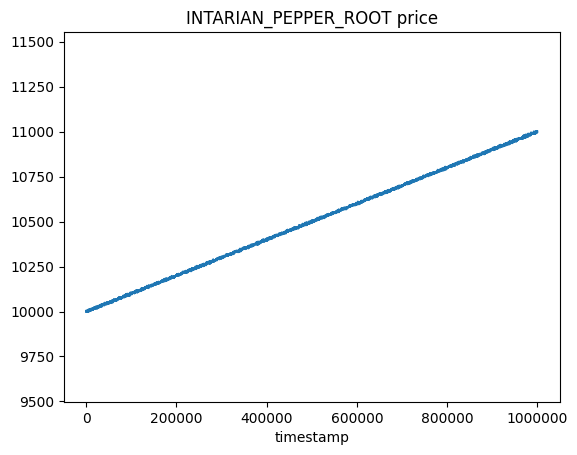

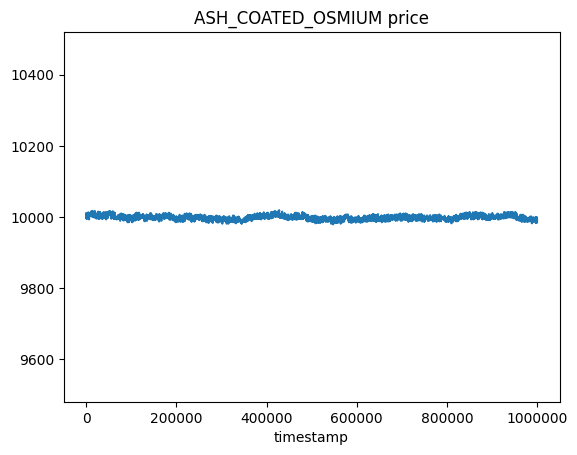

In [10]:

for ticker in tickers:
    # Filter out rows where mid_price is 0 or NaN
    clean = prices[ticker]
    clean = clean[clean > 0]      # removes zeros
    clean = clean.dropna()        # removes NaN (probably already gone but just in case)

    ax = clean.plot(
        title=f"{ticker} price",
        ylim=(clean.min() * 0.95, clean.max() * 1.05),
    )
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.show()

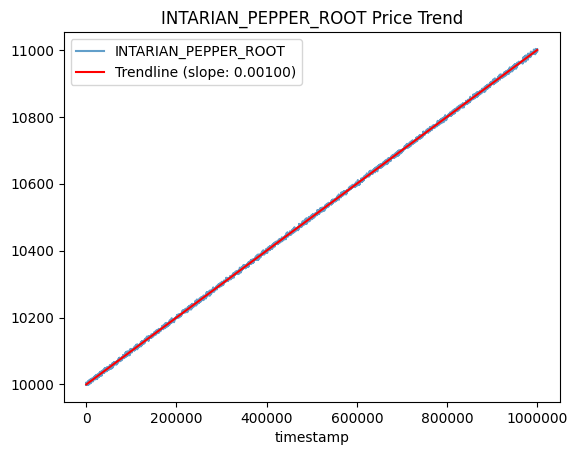

The overall trend step per timestamp tick is: 0.00100


In [ ]:
import numpy as np

ticker = "INTARIAN_PEPPER_ROOT"
clean = prices[ticker][prices[ticker] > 0].dropna()

# Fit a linear regression line to find the overall trend
x = clean.index.values
y = clean.values

slope, intercept = np.polyfit(x, y, 1)

# Plot the actual price and the trendline
plt.figure()
ax = clean.plot(label=ticker, alpha=0.7)
trendline = slope * x + intercept
plt.plot(x, trendline, color='red', label=f'Trendline (slope: {slope:.5f})')
plt.title(f"{ticker} Price Trend")
ax.ticklabel_format(axis="x", style="plain", useOffset=False)
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.legend()
plt.show()

print(f"The overall trend step per timestamp tick is: {slope:.5f}")
print(f"The intercept of the trendline is: {intercept:.2f}")